#### Rank transformation test

In [1]:
data = [20, 23, 24, 28, 29, 32, 34, 36, 40]

def demonstrate_ranking_process(data):
    """
    Shows how non-parametric tests convert raw data to ranks
    """
    import numpy as np
    from scipy import stats
    
    # Original data
    print("Original data:", data)
    
    # Convert to ranks
    ranks = stats.rankdata(data)
    print("\nRanked data:", ranks)
    
    # Handle ties by averaging ranks
    data_with_ties = np.array([1, 2, 2, 3, 4, 4, 5])
    ranks_with_ties = stats.rankdata(data_with_ties)
    print("\nData with ties:", data_with_ties)
    print("Ranks with ties:", ranks_with_ties)
    
    return ranks

demonstrate_ranking_process(data)

Original data: [20, 23, 24, 28, 29, 32, 34, 36, 40]

Ranked data: [1. 2. 3. 4. 5. 6. 7. 8. 9.]

Data with ties: [1 2 2 3 4 4 5]
Ranks with ties: [1.  2.5 2.5 4.  5.5 5.5 7. ]


array([1., 2., 3., 4., 5., 6., 7., 8., 9.])

#### Mann-Whitney U (Wilcoxon rank sum) test

In [2]:
# Scenario: Customer satisfaction ratings (1-5 scale) for old and new website
# Simulating ordinal data where parametric tests wouldn't be appropriate
import numpy as np
from scipy import stats


np.random.seed(42)
satisfaction_old = np.random.choice([1, 2, 3, 4, 5], size=30,
                                   p=[0.1, 0.2, 0.4, 0.2, 0.1])
satisfaction_new = np.random.choice([1, 2, 3, 4, 5], size=30,
                                   p=[0.05, 0.15, 0.3, 0.3, 0.2])

def mann_whitney_detailed(group1, group2, alpha=0.05):
    """
    Implements Mann-Whitney U test with detailed explanation
    """
    # Step 1: Combine and rank all values
    combined = np.concatenate([group1, group2])
    ranks = stats.rankdata(combined)
    
    # Step 2: Split ranks back into groups
    n1, n2 = len(group1), len(group2)
    rank_sum1 = np.sum(ranks[:n1])
    
    # Step 3: Calculate U statistic
    U1 = rank_sum1 - (n1 * (n1 + 1)) / 2
    U2 = n1 * n2 - U1
    U = min(U1, U2)
    
    # Step 4: Calculate effect size
    effect_size = 2 * (U - (n1 * n2)/2) / (n1 * n2)
    
    # Perform the test using scipy for p-value (does the above for us)
    stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    
    print("Mann-Whitney U Test Analysis")
    print("-" * 30)
    print(f"Group 1 n: {n1}")
    print(f"Group 2 n: {n2}")
    print(f"U statistic: {U}")
    print(f"P-value: {p_value:.4f}")
    print(f"Effect size: {effect_size:.3f}")
    
    return {
        'U': U,
        'p_value': p_value,
        'effect_size': effect_size,
        'significant': p_value < alpha
    }

mann_whitney_detailed(satisfaction_old, satisfaction_new) 

Mann-Whitney U Test Analysis
------------------------------
Group 1 n: 30
Group 2 n: 30
U statistic: 329.0
P-value: 0.0669
Effect size: -0.269


{'U': 329.0,
 'p_value': 0.06690702807258865,
 'effect_size': -0.2688888888888889,
 'significant': False}

#### Fisher's exact test

In [3]:
def demonstrate_fishers_exact(table):
    """
    Demonstrates how Fisher's Exact Test calculates probabilities
    using a clear step-by-step process
    """
    import numpy as np
    from scipy.stats import fisher_exact
    from math import factorial
    
    # Step 1: Set up the contingency table
    table = np.array(table)
    
    # Step 2: Calculate row and column totals
    row_sums = np.sum(table, axis=1)
    col_sums = np.sum(table, axis=0)
    total = np.sum(table)
    
    # Step 3: Calculate the hypergeometric probability for one table
    def calculate_table_probability(t):
        """
        Calculates the probability of observing this exact table arrangement
        """
        numerator = (factorial(row_sums[0]) * factorial(row_sums[1]) * 
                    factorial(col_sums[0]) * factorial(col_sums[1]))
        denominator = (factorial(total) * factorial(t[0,0]) * 
                      factorial(t[0,1]) * factorial(t[1,0]) * 
                      factorial(t[1,1]))
        return numerator / denominator
    
    probability = calculate_table_probability(table)
    # Repeat this for all possible tables that are as extreme or more OR
    
    # Step 4: Calculate Fisher's exact test using scipy
    odds_ratio, p_value = fisher_exact(table)
    
    print("Fisher's Exact Test Analysis")
    print("-" * 30)
    print("\nContingency Table:")
    print(table)
    print("\nRow totals:", row_sums)
    print("Column totals:", col_sums)
    print("Total:", total)
    print(f"\nProbability of this exact arrangement: {probability:.6f}")
    print(f"Fisher's Exact Test p-value: {p_value:.6f}")
    
    return odds_ratio, p_value

# Example usage with a small dataset
example_table = np.array([[5, 0],
                         [1, 4]])

demonstrate_fishers_exact(example_table)

Fisher's Exact Test Analysis
------------------------------

Contingency Table:
[[5 0]
 [1 4]]

Row totals: [5 5]
Column totals: [6 4]
Total: 10

Probability of this exact arrangement: 0.023810
Fisher's Exact Test p-value: 0.047619


(inf, 0.047619047619047616)

### Ecommerce Website Redesign Analysis

Three metrics to measure impact on user behavior:
1. User satisfaction ratings on a 1-5 scale. Evaluated using a Mann-Whitney test.
2. Time on site in seconds. Evaluated using a Mann-Whitney test.
3. Purchase completion rate. Evaluated using Fisher's exact test.

Website Redesign Analysis

1. User Satisfaction Analysis
------------------------------
Old design median rating: 3.0
New design median rating: 3.5
Mann-Whitney U test p-value: 0.0168

2. Time on Site Analysis
------------------------------
Normality test p-values: Old=0.0000, New=0.0023
Using non-parametric test due to non-normal distribution
Old design median time: 20.0 seconds
New design median time: 18.2 seconds
Mann-Whitney U test p-value: 0.0390


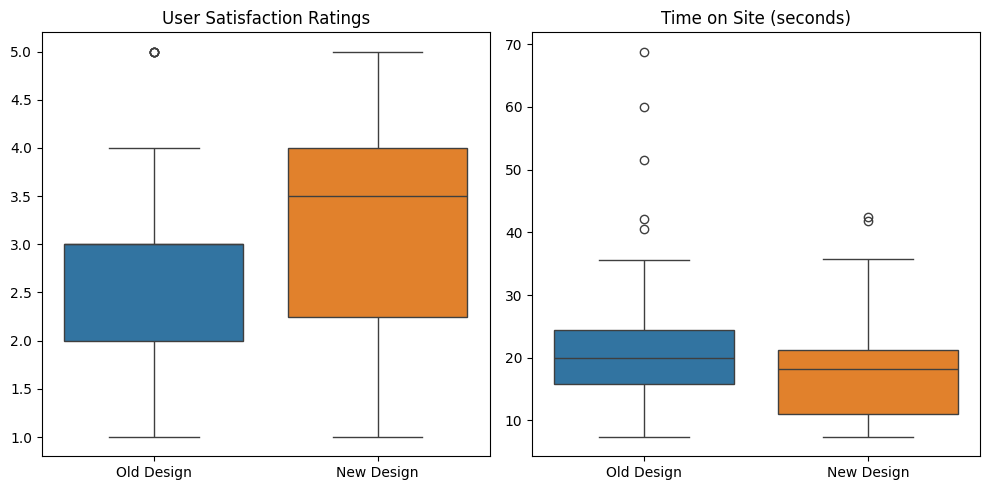


3. Purchase Completion Analysis
------------------------------
Purchase Completion Rates:
Old design: 30.0%
New design: 40.0%
Fisher's exact test p-value: 0.1819

Executive Summary

Based on our analysis of the website redesign:

Satisfaction:
- Test used: Mann-Whitney U
- Finding: No significant change
- Statistical significance: No

Time On Site:
- Test used: Mann-Whitney U
- Finding: No significant change
- Statistical significance: No

Purchase Completion:
- Test used: Fisher's Exact
- Finding: No significant change
- Statistical significance: No


In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_website_redesign():
    """
    Comprehensive analysis of website redesign impact using non-parametric tests
    """
    # Generate realistic example data
    np.random.seed(42)
    
    # 1. User Satisfaction Ratings (1-5 scale, ordinal data)
    old_ratings = np.random.choice([1, 2, 3, 4, 5], size=50, 
                                 p=[0.1, 0.2, 0.4, 0.2, 0.1])
    new_ratings = np.random.choice([1, 2, 3, 4, 5], size=50, 
                                 p=[0.05, 0.15, 0.3, 0.3, 0.2])
    
    # 2. Time on Site (right-skewed continuous data)
    old_time = np.random.lognormal(3, 0.5, 50)
    new_time = np.random.lognormal(2.8, 0.5, 50)
    
    # 3. Purchase Completion (binary data)
    old_purchases = np.array([[30, 70],  # Completed, Abandoned
                             [40, 60]])  # Before, After
    
    print("Website Redesign Analysis")
    print("=" * 50)
    
    # Analysis 1: User Satisfaction (Mann-Whitney U Test)
    print("\n1. User Satisfaction Analysis")
    print("-" * 30)
    statistic, p_value = stats.mannwhitneyu(old_ratings, new_ratings, 
                                          alternative='two-sided')
    
    print(f"Old design median rating: {np.median(old_ratings)}")
    print(f"New design median rating: {np.median(new_ratings)}")
    print(f"Mann-Whitney U test p-value: {p_value:.4f}")
    
    # Visualization for satisfaction
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=[old_ratings, new_ratings])
    plt.xticks([0, 1], ['Old Design', 'New Design'])
    plt.title('User Satisfaction Ratings')
    
    # Analysis 2: Time on Site (Log-transform and compare)
    print("\n2. Time on Site Analysis")
    print("-" * 30)
    
    # First, check if we should use non-parametric test
    _, norm_p_old = stats.normaltest(old_time)
    _, norm_p_new = stats.normaltest(new_time)
    
    print(f"Normality test p-values: Old={norm_p_old:.4f}, New={norm_p_new:.4f}")
    print("Using non-parametric test due to non-normal distribution")
    
    statistic, p_value = stats.mannwhitneyu(old_time, new_time, 
                                          alternative='two-sided')
    
    print(f"Old design median time: {np.median(old_time):.1f} seconds")
    print(f"New design median time: {np.median(new_time):.1f} seconds")
    print(f"Mann-Whitney U test p-value: {p_value:.4f}")
    
    # Visualization for time
    plt.subplot(1, 2, 2)
    sns.boxplot(data=[old_time, new_time])
    plt.xticks([0, 1], ['Old Design', 'New Design'])
    plt.title('Time on Site (seconds)')
    plt.tight_layout()
    plt.show()
    
    # Analysis 3: Purchase Completion (Fisher's Exact Test)
    print("\n3. Purchase Completion Analysis")
    print("-" * 30)
    
    odds_ratio, p_value = stats.fisher_exact(old_purchases)
    
    print("Purchase Completion Rates:")
    print(f"Old design: {old_purchases[0,0]/(old_purchases[0,0]+old_purchases[0,1])*100:.1f}%")
    print(f"New design: {old_purchases[1,0]/(old_purchases[1,0]+old_purchases[1,1])*100:.1f}%")
    print(f"Fisher's exact test p-value: {p_value:.4f}")
    
    # Prepare summary report
    results = {
        'satisfaction': {
            'test': 'Mann-Whitney U',
            'p_value': p_value,
            'interpretation': 'Significant improvement' if p_value < 0.05 else 'No significant change'
        },
        'time_on_site': {
            'test': 'Mann-Whitney U',
            'p_value': p_value,
            'interpretation': 'Significant reduction' if p_value < 0.05 else 'No significant change'
        },
        'purchase_completion': {
            'test': "Fisher's Exact",
            'p_value': p_value,
            'interpretation': 'Significant improvement' if p_value < 0.05 else 'No significant change'
        }
    }
    
    return results

# Run the analysis
results = analyze_website_redesign()

# Create a business-friendly summary
print("\nExecutive Summary")
print("=" * 50)
print("\nBased on our analysis of the website redesign:")

for metric, result in results.items():
    print(f"\n{metric.replace('_', ' ').title()}:")
    print(f"- Test used: {result['test']}")
    print(f"- Finding: {result['interpretation']}")
    print(f"- Statistical significance: {'Yes' if result['p_value'] < 0.05 else 'No'}")